# CardioIA — Fase 2, Parte 2: Classificador de risco (TF-IDF + ML)

Objetivo: classificar frases de sintomas como **alto risco** ou **baixo risco**,
simulando uma triagem clínica automatizada.

Pipeline: `frases (.csv)` → `TF-IDF` → `Logistic Regression` (comparada com `Decision Tree`) → avaliação → análise de vieses e distorções.

> ⚠️ Projeto didático. A base é pequena e simulada; o modelo **não** serve para uso clínico.

In [1]:
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, RepeatedStratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay, confusion_matrix

warnings.filterwarnings("ignore")
SEED = 42
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
pd.set_option("display.max_colwidth", 110)

## 1. Carregando e conhecendo a base

In [2]:
df = pd.read_csv(RAIZ / "data" / "dataset_triagem.csv", encoding="utf-8-sig")
df["n_palavras"] = df["frase"].str.split().str.len()
print(df.shape, "| duplicadas:", df["frase"].duplicated().sum())
print(df["situacao"].value_counts())
df.groupby("situacao")["n_palavras"].describe().round(1)

(120, 3) | duplicadas: 0
situacao
alto risco     60
baixo risco    60
Name: count, dtype: int64


,count,mean,std,min,25%,50%,75%,max
situacao,,,,,,,,
alto risco,60.0,9.2,1.9,6.0,8.0,9.0,11.0,14.0
baixo risco,60.0,8.8,3.0,4.0,7.0,9.0,10.0,20.0


A base é **balanceada** (60/60). Repare no tamanho médio das frases por classe: se as frases de alto risco forem sistematicamente
mais longas, o modelo pode aprender "tamanho" em vez de "gravidade" (via número de termos ativos). Vale ficar atento.

## 2. Separação treino/teste

Divisão **estratificada** 75/25 (90 treino / 30 teste). O vetorizador TF-IDF é ajustado **somente no treino**
(dentro do `Pipeline`) para evitar vazamento de dados.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    df["frase"], df["situacao"], test_size=0.25, stratify=df["situacao"], random_state=SEED)
print(len(X_train), "treino |", len(X_test), "teste")

90 treino | 30 teste


## 3. TF-IDF + modelos

- `strip_accents='unicode'` e `lowercase=True`: "dor súbita" e "dor subita" viram o mesmo termo.
- `ngram_range=(1, 2)`: captura expressões como "falta de ar" e "dor no peito", não só palavras soltas.
- Modelos: **Logistic Regression** (linear, interpretável) e **Decision Tree** (regras) para comparação.

In [4]:
def novo_tfidf():
    return TfidfVectorizer(strip_accents="unicode", lowercase=True, ngram_range=(1, 2), sublinear_tf=True)

modelos = {
    "Logistic Regression": make_pipeline(novo_tfidf(), LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED)),
    "Decision Tree":       make_pipeline(novo_tfidf(), DecisionTreeClassifier(max_depth=5, class_weight="balanced", random_state=SEED)),
}
for nome, m in modelos.items():
    m.fit(X_train, y_train)
    print(f"{nome:20s} acurácia no teste: {accuracy_score(y_test, m.predict(X_test)):.3f}")

Logistic Regression  acurácia no teste: 0.833
Decision Tree        acurácia no teste: 0.700


Com apenas 30 frases de teste, **cada erro vale ~3,3 pontos percentuais**: a acurácia de uma única divisão é uma estimativa ruidosa.
Por isso repetimos uma validação cruzada estratificada (5 dobras × 10 repetições) sobre a base inteira.

In [5]:
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=SEED)
for nome, m in modelos.items():
    s = cross_val_score(m, df["frase"], df["situacao"], cv=cv, scoring="accuracy")
    print(f"{nome:20s} CV acurácia: {s.mean():.3f} ± {s.std():.3f}  (min {s.min():.2f} / max {s.max():.2f})")

Logistic Regression  CV acurácia: 0.850 ± 0.062  (min 0.71 / max 0.96)


Decision Tree        CV acurácia: 0.767 ± 0.069  (min 0.58 / max 0.92)


## 4. Avaliação do modelo escolhido (Logistic Regression)

              precision    recall  f1-score   support

  alto risco      0.812     0.867     0.839        15
 baixo risco      0.857     0.800     0.828        15

    accuracy                          0.833        30
   macro avg      0.835     0.833     0.833        30
weighted avg      0.835     0.833     0.833        30



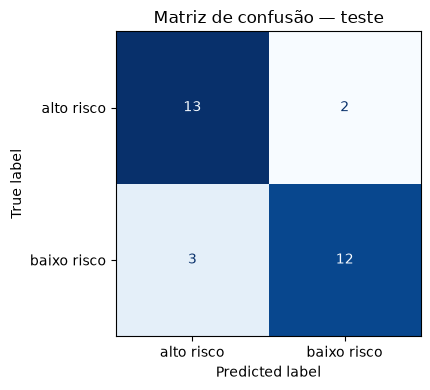

In [6]:
modelo = modelos["Logistic Regression"]
y_pred = modelo.predict(X_test)
print(classification_report(y_test, y_pred, digits=3))

fig, ax = plt.subplots(figsize=(4.5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Matriz de confusão — teste")
plt.tight_layout()
(RAIZ / "assets").mkdir(exist_ok=True)
plt.savefig(RAIZ / "assets" / "matriz_confusao.png", dpi=130)
plt.show()

**Leitura clínica:** em triagem, os dois erros não custam o mesmo.
- *Falso negativo* (alto risco classificado como baixo) → paciente grave não priorizado. **É o erro perigoso.**
- *Falso positivo* (baixo → alto) → uso desnecessário de recursos.

Por isso olhamos o **recall de "alto risco"** com mais atenção que a acurácia.

In [7]:
erros = pd.DataFrame({"frase": X_test, "real": y_test, "previsto": y_pred})
erros[erros.real != erros.previsto]

,frase,real,previsto
71,um pequeno corte no dedo que já está cicatrizando,baixo risco,alto risco
56,perdi os sentidos por alguns segundos enquanto caminhava,alto risco,baixo risco
44,tive convulsão e depois fiquei sem conseguir mexer o braço,alto risco,baixo risco
99,"senti uma pontada rápida no peito ao espirrar, que já passou",baixo risco,alto risco
15,sinto sono durante a tarde,baixo risco,alto risco


## 5. O que o modelo aprendeu? (interpretabilidade)

Isso permite auditar se o modelo se apoia em sinais clínicos reais ou em artefatos do texto.

In [8]:
vec, lr = modelo[0], modelo[-1]
termos = np.array(vec.get_feature_names_out())
# classes_ é ordenado alfabeticamente: ['alto risco', 'baixo risco'].
# Em regressão logística binária, coef > 0 favorece classes_[1] ('baixo risco').
print("classes_:", list(lr.classes_))
ordem = np.argsort(lr.coef_[0])
print("\nTermos que mais indicam ALTO risco:\n ", ", ".join(termos[ordem[:15]]))
print("\nTermos que mais indicam BAIXO risco:\n ", ", ".join(termos[ordem[::-1][:15]]))

classes_: ['alto risco', 'baixo risco']

Termos que mais indicam ALTO risco:
  peito, no peito, no, com, suor, suor frio, frio, dor no, falta, falta de, de ar, ar, nausea, desmaiei, forte

Termos que mais indicam BAIXO risco:
  leve, depois, depois de, de, por, sem, na, ao, dor de, causa, por causa, leve no, dormir, leve dor, sem febre


## 6. Análise de vieses e distorções

Um modelo treinado com poucas frases tende a aprender **atalhos lexicais**. Vamos testá-lo de propósito com frases-sonda,
em vez de confiar só na acurácia.

In [9]:
IDX_ALTO = list(modelo.classes_).index("alto risco")

def prever(frases):
    proba = modelo.predict_proba(frases)[:, IDX_ALTO]
    return pd.DataFrame({"frase": frases, "P(alto risco)": proba.round(2),
                         "previsto": np.where(proba >= 0.5, "alto risco", "baixo risco")})

### 6.1 Negação — o modelo entende "não" e "sem"?

In [10]:
prever([
    "tenho dor no peito e falta de ar",
    "não tenho dor no peito nem falta de ar",
    "estou sem dor no peito e sem falta de ar",
    "sinto dor no peito",
    "meu vizinho teve dor no peito mas eu estou bem",
])

,frase,P(alto risco),previsto
0,tenho dor no peito e falta de ar,0.74,alto risco
1,não tenho dor no peito nem falta de ar,0.63,alto risco
2,estou sem dor no peito e sem falta de ar,0.60,alto risco
3,sinto dor no peito,0.72,alto risco
4,meu vizinho teve dor no peito mas eu estou bem,0.64,alto risco


Modelos baseados em TF-IDF tratam o texto como "saco de palavras": "dor no peito" pesa para alto risco mesmo quando negada
(a menos que a base contenha exemplos suficientes de negação). Esse tipo de falha é uma **distorção sistemática**, não um erro aleatório.

### 6.2 Sintomas graves com palavras que o modelo não viu no treino

In [11]:
prever([
    "meu braço esquerdo formiga e sinto o peito pesado",
    "sinto uma pressão forte em cima do estômago, suando muito e tonto",
    "meu rosto está torto e não consigo sorrir",
    "estou muito mal e quero ir ao hospital",
    "dor leve no peito depois de tossir muito",
])

,frase,P(alto risco),previsto
0,meu braço esquerdo formiga e sinto o peito pesado,0.62,alto risco
1,"sinto uma pressão forte em cima do estômago, suando muito e tonto",0.51,alto risco
2,meu rosto está torto e não consigo sorrir,0.55,alto risco
3,estou muito mal e quero ir ao hospital,0.42,baixo risco
4,dor leve no peito depois de tossir muito,0.37,baixo risco


Sintomas graves em **vocabulário coloquial** são o principal risco de falso negativo: o modelo só conhece o vocabulário da base de treino.

### 6.3 Viés demográfico — a mesma queixa com perfis diferentes

Trocamos apenas o perfil do paciente. Em um sistema justo, a previsão **não deveria mudar** por causa de sexo
quando os sintomas são idênticos (a idade pode ter relevância clínica, mas o modelo não deveria inferi-la de um número solto).

In [12]:
queixas = ["com dor no peito e suor frio", "com tosse leve e coriza", "com cansaço depois do trabalho"]
perfis = ["um homem de 40 anos", "uma mulher de 40 anos", "um homem de 70 anos", "uma mulher de 70 anos", "uma criança", "meu pai", "minha mãe"]
linhas = [f"{p} {q}" for q in queixas for p in perfis]
res = prever(linhas)
res["queixa"] = [q for q in queixas for _ in perfis]
res["perfil"] = [p for _ in queixas for p in perfis]
res.pivot(index="perfil", columns="queixa", values="P(alto risco)")

queixa,com cansaço depois do trabalho,com dor no peito e suor frio,com tosse leve e coriza
perfil,,,
meu pai,0.39,0.75,0.39
minha mãe,0.40,0.75,0.40
um homem de 40 anos,0.35,0.62,0.35
um homem de 70 anos,0.36,0.64,0.36
uma criança,0.37,0.77,0.37
uma mulher de 40 anos,0.37,0.65,0.38
uma mulher de 70 anos,0.39,0.67,0.39


In [13]:
spread = res.groupby("queixa")["P(alto risco)"].agg(["min", "max"])
spread["amplitude"] = (spread["max"] - spread["min"]).round(2)
spread

,min,max,amplitude
queixa,,,
com cansaço depois do trabalho,0.35,0.40,0.05
com dor no peito e suor frio,0.62,0.77,0.15
com tosse leve e coriza,0.35,0.40,0.05


A **amplitude** mostra quanto a probabilidade oscila apenas por mudar o perfil. Se for relevante, o modelo está usando termos demográficos
como sinal de risco — indesejável, especialmente porque na cardiologia mulheres frequentemente têm apresentações atípicas de infarto
(ver Fase 1) e podem ser sistematicamente subestimadas.

### 6.4 Ajustando o limiar de decisão para favorecer o recall de alto risco

In [14]:
p_alto = modelo.predict_proba(X_test)[:, IDX_ALTO]
linhas = []
for lim in (0.5, 0.4, 0.3, 0.2):
    pred = np.where(p_alto >= lim, "alto risco", "baixo risco")
    cm = confusion_matrix(y_test, pred, labels=["alto risco", "baixo risco"])
    linhas.append({"limiar": lim, "acurácia": round(accuracy_score(y_test, pred), 3),
                   "falsos negativos": cm[0, 1], "falsos positivos": cm[1, 0]})
pd.DataFrame(linhas)

,limiar,acurácia,falsos negativos,falsos positivos
0,0.5,0.833,2,3
1,0.4,0.767,0,7
2,0.3,0.533,0,14
3,0.2,0.500,0,15


Baixar o limiar troca falsos negativos (perigosos) por falsos positivos (custosos, mas seguros) — uma decisão de **política clínica**, não puramente técnica.

## 7. Aplicando o classificador às frases da Parte 1

In [15]:
frases_p1 = [l.strip() for l in (RAIZ / "data" / "frases_sintomas.txt").read_text(encoding="utf-8").splitlines() if l.strip()]
prever(frases_p1)

,frase,P(alto risco),previsto
0,Há dois dias estou com uma dor no peito que irradia para o braço esquerdo e piora quando faço esforço físi...,0.68,alto risco
1,"Sinto cansaço constante há uma semana, mesmo depois de descansar, e meus tornozelos ficam inchados no fim ...",0.40,baixo risco
2,"Desde ontem sinto o coração disparado, com palpitações que vêm e vão, e fico tonto quando levanto rápido d...",0.55,alto risco
3,"Acordei hoje com a boca torta, fraqueza no lado direito do corpo e dificuldade para falar, e não consegui ...",0.64,alto risco
4,"Faz três dias que tenho uma dor de cabeça forte e zumbido no ouvido, e quando medi hoje minha pressão esta...",0.53,alto risco
5,Nas últimas semanas sinto falta de ar ao subir escadas e preciso dormir com dois travesseiros para consegu...,0.52,alto risco
6,"Depois de um voo de dez horas, minha perna esquerda ficou inchada e dolorida, e agora sinto falta de ar de...",0.57,alto risco
7,Há quatro dias estou com febre e uma dor no peito que piora quando me deito e melhora quando me sento incl...,0.61,alto risco
8,"Desmaiei ontem enquanto esperava na fila do mercado, e antes disso tive tontura e a visão escureceu, então...",0.47,baixo risco
9,"Sinto um aperto no tórax toda vez que caminho rápido na rua, mas ele passa em poucos minutos quando eu par...",0.53,alto risco


## 8. Conclusões e limitações

**Resultados observados (SEED=42):**
- Logistic Regression: 83,3% de acurácia no teste (25/30) e 85,0% ± 6,2 em validação cruzada; Decision Tree: 70,0% e 76,7% ± 6,9.
- Recall de "alto risco" no teste: 86,7% (2 falsos negativos em 15), um deles um desmaio descrito como "perdi os sentidos".
- **Negação não é entendida**: "não tenho dor no peito nem falta de ar" recebe P(alto risco)=0,63, praticamente igual à frase sem negação (0,74).
- **Atalhos lexicais**: termos genéricos como "no" e "com" aparecem entre os que mais indicam alto risco, e "leve", "depois de" e "sem" dominam o baixo risco.
- **Perfil do paciente**: a oscilação por perfil é pequena em queixas leves (0,05), mas chega a 0,15 na queixa de dor no peito; "meu pai", "minha mãe" e "uma criança" recebem mais risco que "homem/mulher de N anos" — efeito de quais perfis aparecem na base, não de lógica clínica.

**Limitações:**
- A base tem **120 frases escritas pelos autores**: o desempenho medido é otimista, pois treino e teste compartilham estilo e vocabulário.
- O modelo funciona como **detector de palavras-chave de gravidade**; tende a falhar em negação e em vocabulário coloquial novo.
- Os rótulos foram atribuídos pelos autores (não por médicos) → **viés de rotulagem** não auditado.
- Governança: antes de qualquer uso real seriam necessários dados reais anonimizados (LGPD), rótulos clínicos validados,
  avaliação por subgrupos (sexo, idade) e um humano sempre no circuito de decisão.
- Próximos passos: mais dados, tratamento de negação, embeddings/modelos de linguagem em português, calibração de probabilidades.